In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-25 08:55:36.377535


# Gaussian mixture model

GMM on a subset of the data as analysis strategy for separating signal and noise

In [28]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150
#sc.set_figure_params(scanpy=True)

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [4]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_02/03_annotated"

### Read and process adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
adata_ref = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))

# have to use the version of the dataset that has the transgenes to draw positive and negative signal

#bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
# this is the dataset with adata.var subsetted to 475, 5 transgenes witheld


In [6]:
transgenes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

In [7]:
adata.X[:5, :5].toarray()

array([[ 0.       ,  8.659507 ,  0.       ,  8.659507 ,  0.       ],
       [ 7.125473 ,  9.021909 ,  6.028468 ,  9.2450285,  0.       ],
       [ 6.24855  ,  6.24855  ,  7.85644  ,  8.811713 ,  0.       ],
       [ 0.       ,  7.644289 ,  0.       ,  0.       ,  0.       ],
       [ 0.       ,  9.205453 ,  0.       , 10.016328 ,  0.       ]],
      dtype=float32)

In [8]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

# Gaussian Mixture Models

## Raw counts
* Gaussian Mixture Models (GMMs) were fitted directly on raw count values (adata[:, g].X).
* No transformation or normalization applied.
* Thresholding and high-expression classification were both based on raw counts.
* Dual-positive identification was based on raw thresholds.
* Thresholds visualize the percentile boundary inside the GMM’s high-expression cluster, not the mathematical GMM boundary between components. Indicates top X% of cells that the model already believes are in the high mode.

The thresholds in this script were set empirically from the GMM’s high-expression cluster.
Specifically, after fitting a 3-component Gaussian Mixture Model to each gene’s raw count distribution, cells assigned with >99% posterior probability to the highest-mean cluster were selected.
Within those cells, the expression cutoff (thr_expr) was defined as the 99th percentile (within_cluster_q = 0.99) of expression values.
Thus, the dashed threshold lines in the plot represent the top 1% expression boundary within the GMM-defined high-expression mode for each gene.

In [9]:
#genes = ['EGFP_Seq1', 'tdTomato_Seq2']
#n_components = 3
#prob_threshold = 0.99
#within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)



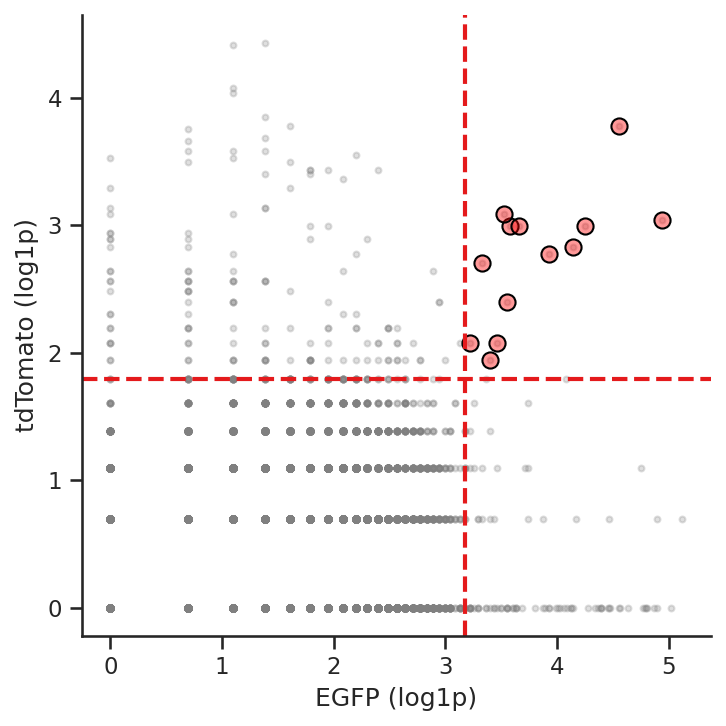

In [10]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 2
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

# Fit GMM on raw counts
for g in genes:
    x_raw = to_dense(adata[:, g].X).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_raw)
    probs = gmm.predict_proba(x_raw)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high = x_raw.ravel()[high_mask]

    thr_raw = np.percentile(x_high, within_cluster_q * 100) if x_high.size > 0 else means[high_cluster]

    hi_mask = (high_mask.ravel()) & (x_raw.ravel() > thr_raw)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_raw": x_raw.ravel(),
        "thr_raw": thr_raw,
    }

# Dual-high cells
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values

# Extract arrays
x_egfp_raw = gmm_results["EGFP_Seq1"]["x_raw"]
x_td_raw   = gmm_results["tdTomato_Seq2"]["x_raw"]
thr_egfp   = gmm_results["EGFP_Seq1"]["thr_raw"]
thr_td     = gmm_results["tdTomato_Seq2"]["thr_raw"]

# log1p versions
x_egfp_log = np.log1p(x_egfp_raw)
x_td_log   = np.log1p(x_td_raw)
thr_egfp_log = np.log1p(thr_egfp)
thr_td_log   = np.log1p(thr_td)

# Plotting (single panel: log1p only)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5, 5), dpi=150)
ax = plt.gca()

# Points
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

# Thresholds (converted from raw)
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p)")
ax.set_ylabel("tdTomato (log1p)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [11]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
bpoikicj-1-1
cbhmmeof-1-1
akcoadof-1-2
bgmdeeeb-1-2
eaojikbl-1-2
hjjgalia-1-2
hjjkhdhk-1-2
mnhcfodp-1-2
bmjgagok-1-3
ijnggkoc-1-3
llknggjo-1-3
llmfnafp-1-3
llmgffik-1-3

Total: 13 barcodes printed.


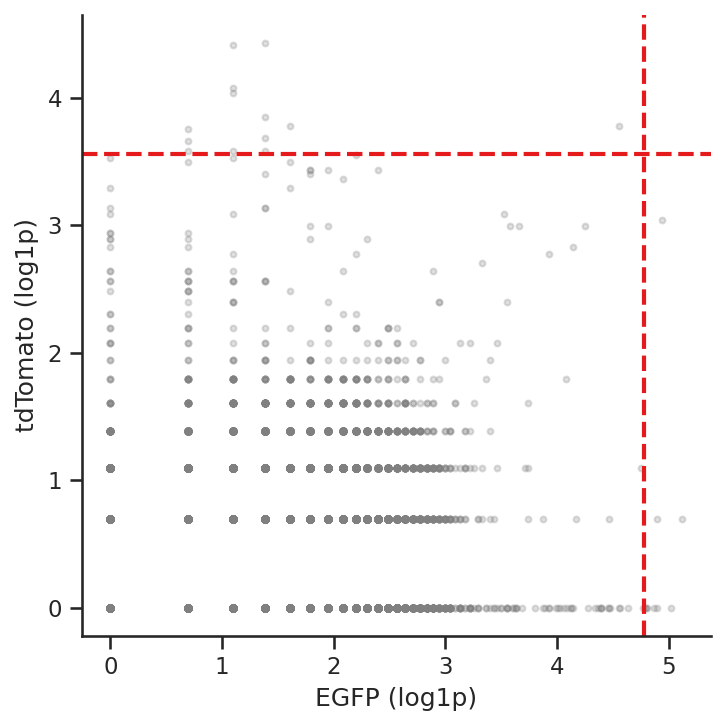

In [12]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

# Fit GMM on raw counts
for g in genes:
    x_raw = to_dense(adata[:, g].X).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_raw)
    probs = gmm.predict_proba(x_raw)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high = x_raw.ravel()[high_mask]

    thr_raw = np.percentile(x_high, within_cluster_q * 100) if x_high.size > 0 else means[high_cluster]

    hi_mask = (high_mask.ravel()) & (x_raw.ravel() > thr_raw)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_raw": x_raw.ravel(),
        "thr_raw": thr_raw,
    }

# Dual-high cells
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values

# Extract arrays
x_egfp_raw = gmm_results["EGFP_Seq1"]["x_raw"]
x_td_raw   = gmm_results["tdTomato_Seq2"]["x_raw"]
thr_egfp   = gmm_results["EGFP_Seq1"]["thr_raw"]
thr_td     = gmm_results["tdTomato_Seq2"]["thr_raw"]

# log1p versions
x_egfp_log = np.log1p(x_egfp_raw)
x_td_log   = np.log1p(x_td_raw)
thr_egfp_log = np.log1p(thr_egfp)
thr_td_log   = np.log1p(thr_td)

# Plotting (single panel: log1p only)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5, 5), dpi=150)
ax = plt.gca()

# Points
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

# Thresholds (converted from raw)
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p)")
ax.set_ylabel("tdTomato (log1p)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [13]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:

Total: 0 barcodes printed.


## GMM on log1p-transformed raw counts (hybrid: raw thresholding, no normalization)
* GMMs were fitted on log1p-transformed counts (np.log1p(x_raw)).
* Thresholding was still applied in raw count space (using original x_raw).
* High-expression classification combined log1p-based model with raw thresholds.
* Plot and axis labels reflect raw count scale.
* This hybrid method provided better identification of validated dual-high cells.

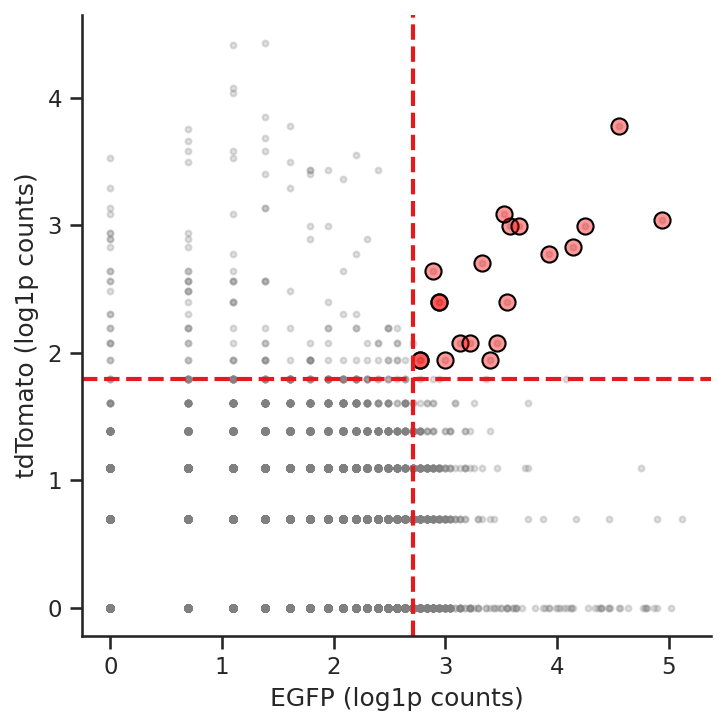

In [15]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 2
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

# Fit GMM on log1p-transformed counts, but thresholds will be back-transformed to raw
for g in genes:
    x_raw = to_dense(adata[:, g].X)
    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p.ravel()[high_mask]

    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0
        else means[high_cluster]
    )

    hi_mask = high_mask & (x_log1p.ravel() > thr_log)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {"x_raw": x_raw, "x_log": x_log1p.ravel(), "thr_log": thr_log}

# Dual-positive label
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values

# Extract values
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plotting (single panel, log1p only) ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

# Scatter all points
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

# Highlight dual-high cells
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

# Threshold lines (in log1p space)
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [16]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
acpnmbio-1-0
blhlbahg-1-0
agbmnepe-1-1
apeeemip-1-1
bpoikicj-1-1
cbhmmeof-1-1
akcoadof-1-2
bgmdeeeb-1-2
eaojikbl-1-2
hjjgalia-1-2
hjjkhdhk-1-2
mnhcfodp-1-2
bmjgagok-1-3
dgdipikp-1-3
dlanhnop-1-3
ijnggkoc-1-3
llklbaph-1-3
llknggjo-1-3
llmfnafp-1-3
llmgffik-1-3

Total: 20 barcodes printed.


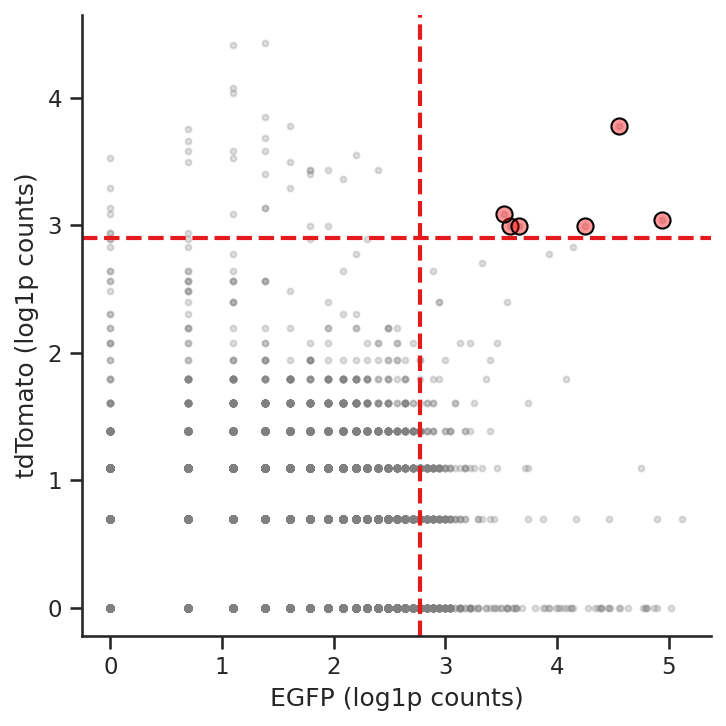

In [17]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

# Fit GMM on log1p-transformed counts, but thresholds will be back-transformed to raw
for g in genes:
    x_raw = to_dense(adata[:, g].X)
    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p.ravel()[high_mask]

    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0
        else means[high_cluster]
    )

    hi_mask = high_mask & (x_log1p.ravel() > thr_log)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {"x_raw": x_raw, "x_log": x_log1p.ravel(), "thr_log": thr_log}

# Dual-positive label
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values

# Extract values
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plotting (single panel, log1p only) ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

# Scatter all points
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

# Highlight dual-high cells
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

# Threshold lines (in log1p space)
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [18]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
bpoikicj-1-1
akcoadof-1-2
bgmdeeeb-1-2
hjjgalia-1-2
bmjgagok-1-3
ijnggkoc-1-3

Total: 6 barcodes printed.


# log1p all

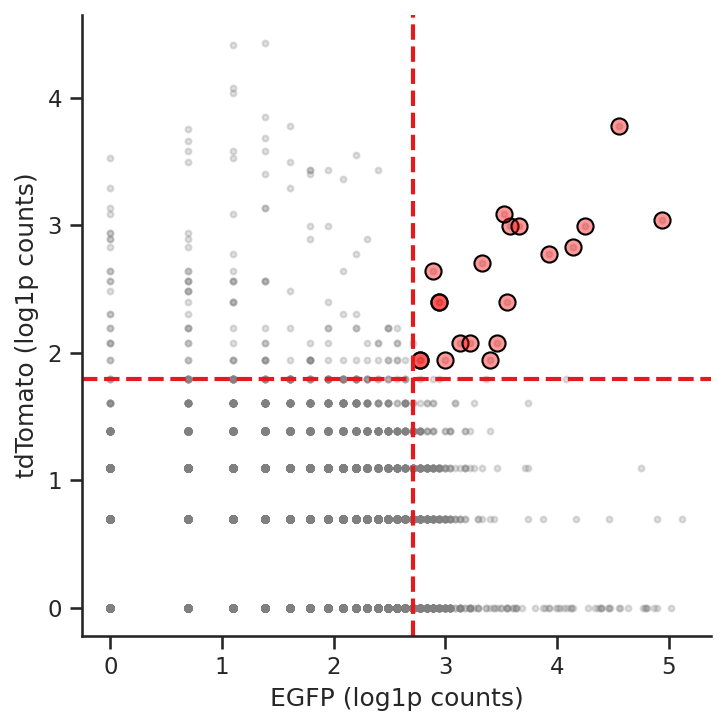

In [19]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 2
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

# Fit GMM on log1p-transformed counts AND compute thresholds in log1p space
for g in genes:
    x_raw = to_dense(adata[:, g].X)
    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    # GMM is trained directly on log1p data
    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    # Identify cells belonging to high cluster
    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p.ravel()[high_mask]

    # Threshold also computed in log1p space
    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0
        else means[high_cluster]
    )

    # Classification also done in log1p space
    hi_mask = high_mask & (x_log1p.ravel() > thr_log)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_log": x_log1p.ravel(),
        "thr_log": thr_log,
    }

# Dual-positive label entirely in log1p space
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values

# Extract log1p arrays
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plotting: log1p-only visualization (no jitter) ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

# All points
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

# Dual-high cells
ax.scatter(
    x_egfp_log[dual], x_td_log[dual],
    s=60, facecolors=(1,0,0,0.4), edgecolors="black"
)

# Threshold lines in log1p space
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [20]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
acpnmbio-1-0
blhlbahg-1-0
agbmnepe-1-1
apeeemip-1-1
bpoikicj-1-1
cbhmmeof-1-1
akcoadof-1-2
bgmdeeeb-1-2
eaojikbl-1-2
hjjgalia-1-2
hjjkhdhk-1-2
mnhcfodp-1-2
bmjgagok-1-3
dgdipikp-1-3
dlanhnop-1-3
ijnggkoc-1-3
llklbaph-1-3
llknggjo-1-3
llmfnafp-1-3
llmgffik-1-3

Total: 20 barcodes printed.


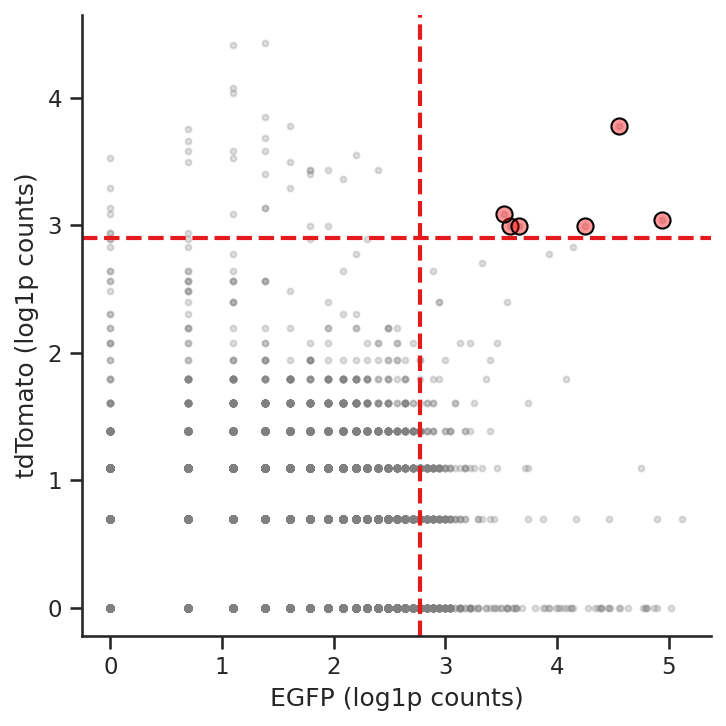

In [21]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

# Fit GMM on log1p-transformed counts AND compute thresholds in log1p space
for g in genes:
    x_raw = to_dense(adata[:, g].X)
    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    # GMM is trained directly on log1p data
    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    # Identify cells belonging to high cluster
    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p.ravel()[high_mask]

    # Threshold also computed in log1p space
    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0
        else means[high_cluster]
    )

    # Classification also done in log1p space
    hi_mask = high_mask & (x_log1p.ravel() > thr_log)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_log": x_log1p.ravel(),
        "thr_log": thr_log,
    }

# Dual-positive label entirely in log1p space
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values

# Extract log1p arrays
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plotting: log1p-only visualization (no jitter) ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

# All points
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

# Dual-high cells
ax.scatter(
    x_egfp_log[dual], x_td_log[dual],
    s=60, facecolors=(1,0,0,0.4), edgecolors="black"
)

# Threshold lines in log1p space
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

In [22]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
bpoikicj-1-1
akcoadof-1-2
bgmdeeeb-1-2
hjjgalia-1-2
bmjgagok-1-3
ijnggkoc-1-3

Total: 6 barcodes printed.


## GMM cell area normalization

EGFP_Seq1: thr_log=0.28, n_hi=225
tdTomato_Seq2: thr_log=0.10, n_hi=151

Dual positives (area-normalized): 9/97027


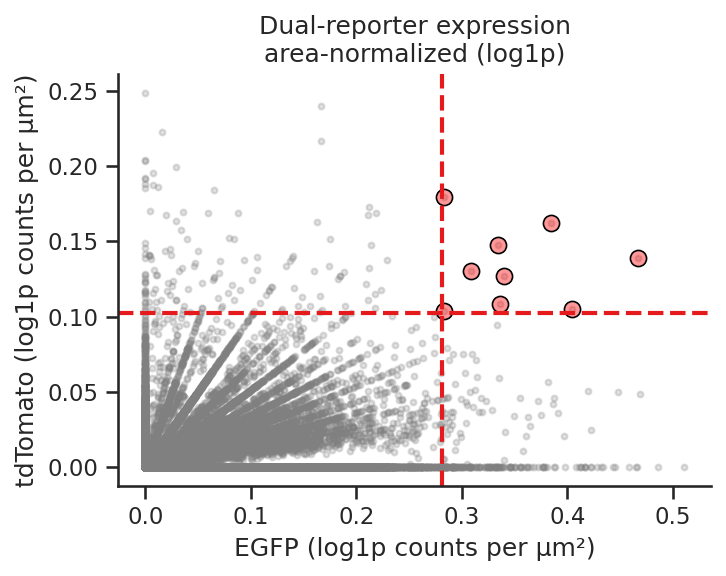

In [23]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 2
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# True area normalization: counts / area  (no arbitrary scaling)
cell_area = adata.obs['cell_area'].values

gmm_results = {}

for g in genes:
    x_raw = to_dense(adata[:, g].X)

    # ---- TRUE normalization ----
    # counts per µm², then log1p
    x_norm = x_raw / cell_area
    x_log = np.log1p(x_norm).reshape(-1, 1)

    # ---- Fit GMM on log-normalized counts ----
    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log)
    probs = gmm.predict_proba(x_log)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    # cluster membership
    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log.ravel()[high_mask]

    # threshold for the high-expression cluster
    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0
        else means[high_cluster]
    )

    hi_mask = high_mask & (x_log.ravel() > thr_log)
    adata.obs[f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_log": x_log.ravel(),
        "thr_log": thr_log,
    }

    print(f"{g}: thr_log={thr_log:.2f}, n_hi={hi_mask.sum()}")

# ---- Dual-high call ----
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'].values
print(f"\nDual positives (area-normalized): {dual.sum()}/{adata.n_obs}")

# ---- Extract plotting values ----
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plot ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5, 4), dpi=150)
ax = plt.gca()

# All cells
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

# Dual-high calls
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black", linewidths=0.8)

# Thresholds
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts per µm²)")
ax.set_ylabel("tdTomato (log1p counts per µm²)")
ax.set_title("Dual-reporter expression\narea-normalized (log1p)")

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
ghgmgnmc-1-0
nkhcpfbi-1-0
geafadld-1-1
gdogfegp-1-2
gjeoheka-1-2
njkcpook-1-2
nkipdhjo-1-2
dlanhnop-1-3
nkbdbnnd-1-3

Total: 9 barcodes printed.


# SINGLE GAUSSIAN

We fit a Gaussian distribution to the log1p-transformed counts fitted on only cells with greater than 1 count for each gene. Justification: Below 1 count is background noise. We only thresholded on expression higher than 99% of the Gaussian.

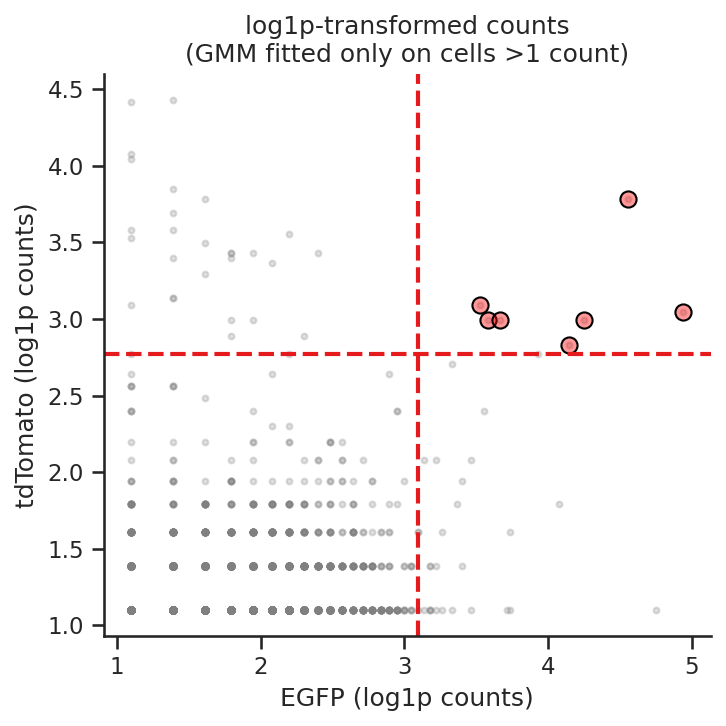

In [25]:
# HELP FROM RITA 
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 1
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# ---- compute raw counts once for both genes ----
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# ---- shared filter: both genes > 1 ----
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gmm_results = {}

# Fit GMM on log1p-transformed counts
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)

    # subset consistently
    x_raw = x_raw_full[bg_filter]

    x_log1p = np.log1p(x_raw).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log1p)
    probs = gmm.predict_proba(x_log1p)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high_log = x_log1p.ravel()[high_mask]

    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0
        else means[high_cluster]
    )

    hi_mask = high_mask & (x_log1p.ravel() > thr_log)

    # assign safely
    adata.obs[f"{g}_hi"] = False
    adata.obs.loc[bg_filter, f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_log": x_log1p.ravel(),
        "thr_log": thr_log
    }

# Dual-positive label
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)

# extract matching subset for plotting
dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plotting (single panel, log1p only) ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("log1p-transformed counts\n(GMM fitted only on cells >1 count)")

sns.despine()
plt.tight_layout()
plt.show()

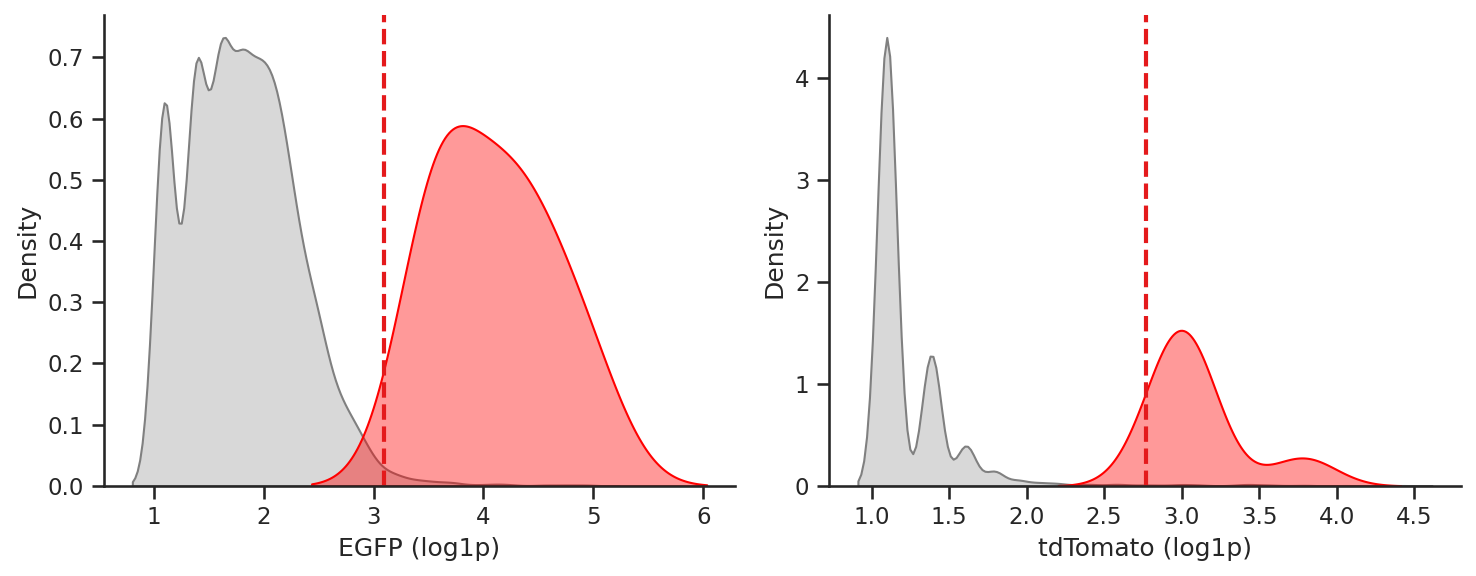

In [26]:
sns.set_theme(style="ticks")

# Pull from your existing gmm_results
x_egfp = gmm_results["EGFP_Seq1"]["x_log"]
x_td   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td   = gmm_results["tdTomato_Seq2"]["thr_log"]

# Dual-high mask already defined:
# dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

plt.figure(figsize=(10,4), dpi=150)

# ----------------------------
# Left subplot: EGFP KDE
# ----------------------------
ax1 = plt.subplot(1, 2, 1)

sns.kdeplot(x_egfp, fill=True, color="gray", alpha=0.3, ax=ax1)
sns.kdeplot(x_egfp[dual], fill=True, color="red", alpha=0.4, ax=ax1)

ax1.axvline(thr_egfp, color="#e41a1c", ls="--", lw=2)
ax1.set_xlabel("EGFP (log1p)")
ax1.set_title("")

# ----------------------------
# Right subplot: tdTomato KDE
# ----------------------------
ax2 = plt.subplot(1, 2, 2)

sns.kdeplot(x_td, fill=True, color="gray", alpha=0.3, ax=ax2)
sns.kdeplot(x_td[dual], fill=True, color="red", alpha=0.4, ax=ax2)

ax2.axvline(thr_td, color="#e41a1c", ls="--", lw=2)
ax2.set_xlabel("tdTomato (log1p)")
ax2.set_title("")

sns.despine()
plt.tight_layout()
plt.show()

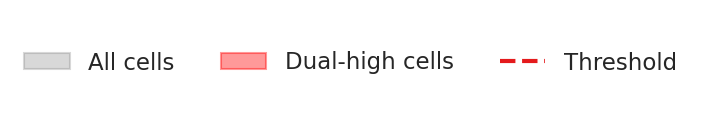

In [29]:
plt.figure(figsize=(4, 1), dpi=150)

# Matching visual elements
all_cells_patch = mpatches.Patch(color="gray", alpha=0.3, label="All cells")
dual_patch      = mpatches.Patch(color="red",  alpha=0.4, label="Dual-high cells")
thr_line        = mlines.Line2D([], [], color="#e41a1c", ls="--", lw=2, label="Threshold")

plt.legend(
    handles=[all_cells_patch, dual_patch, thr_line],
    loc="center",
    frameon=False,
    ncol=3
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [30]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
bpoikicj-1-1
akcoadof-1-2
bgmdeeeb-1-2
hjjgalia-1-2
bmjgagok-1-3
ijnggkoc-1-3
llmgffik-1-3

Total: 7 barcodes printed.


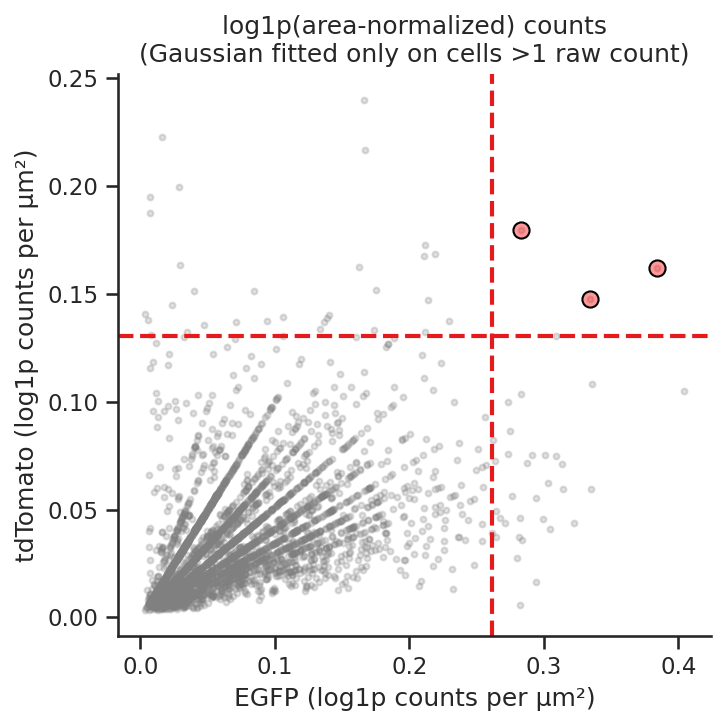

In [31]:
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 1
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# ---- raw counts for both genes (for filtering only) ----
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# ---- shared filter: require >1 raw count in BOTH genes ----
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

# ---- cell area for normalization ----
cell_area = adata.obs['cell_area'].values

gmm_results = {}

# ---- Fit 1-component GMM on log1p(area-normalized counts) ----
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)

    # apply same filter
    x_raw = x_raw_full[bg_filter]

    # area normalization: counts per µm²
    x_norm = x_raw / cell_area[bg_filter]

    # log1p
    x_log = np.log1p(x_norm).reshape(-1, 1)

    # 1-component Gaussian
    gmm = GaussianMixture(n_components=1, random_state=0).fit(x_log)
    probs = gmm.predict_proba(x_log)
    means = gmm.means_.flatten()

    high_cluster = 0  # only one component
    high_mask = probs[:, high_cluster] > prob_threshold  # effectively all True

    x_high_log = x_log.ravel()[high_mask]

    thr_log = (
        np.percentile(x_high_log, within_cluster_q * 100)
        if x_high_log.size > 0 else means[0]
    )

    hi_mask = x_log.ravel() > thr_log

    # assign back to full obs with safe indexing
    adata.obs[f"{g}_hi"] = False
    adata.obs.loc[bg_filter, f"{g}_hi"] = hi_mask

    gmm_results[g] = {
        "x_log": x_log.ravel(),
        "thr_log": thr_log
    }

# ---- dual-high ----
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)

dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# ---- extract values for plotting ----
x_egfp_log = gmm_results["EGFP_Seq1"]["x_log"]
x_td_log   = gmm_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gmm_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gmm_results["tdTomato_Seq2"]["thr_log"]

# ---- Plot ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts per µm²)")
ax.set_ylabel("tdTomato (log1p counts per µm²)")
ax.set_title("log1p(area-normalized) counts\n(Gaussian fitted only on cells >1 raw count)")

sns.despine()
plt.tight_layout()
plt.show()

In [32]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
geafadld-1-1
nkipdhjo-1-2
dlanhnop-1-3

Total: 3 barcodes printed.


# SINGLE GAUSSIAN SIMPLIFIED

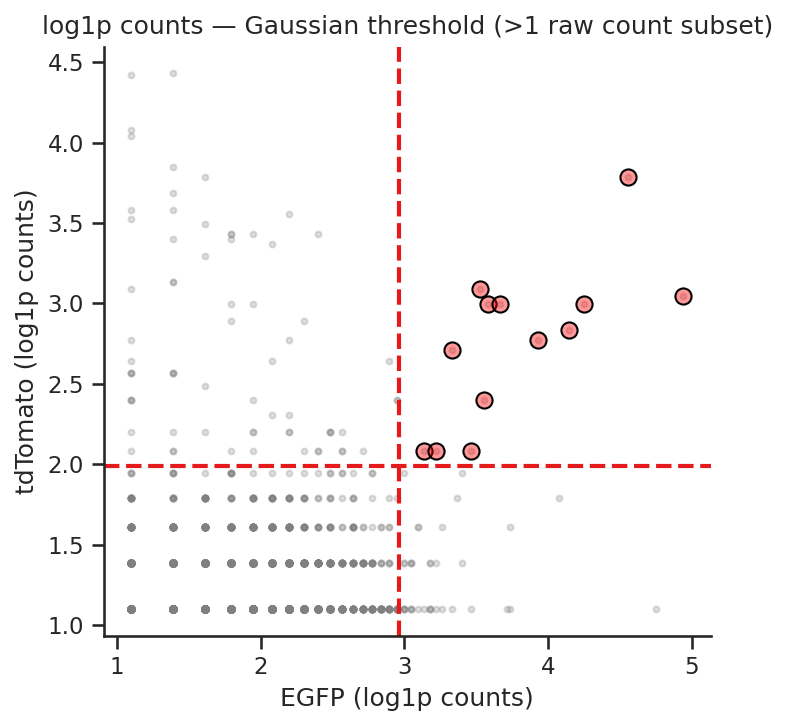

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture  # used only for 1-comp but we remove "posterior" usage

sns.set_theme(style="ticks")

adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# Filter: only cells with >1 raw count in BOTH genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(counts) --------
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Fit a simple one-component Gaussian
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 * sd
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# Dual-high
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)

dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# -------- Plot --------
plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("log1p counts — Gaussian threshold (>1 raw count subset)")

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
apeeemip-1-1
bpoikicj-1-1
cbhmmeof-1-1
akcoadof-1-2
bgmdeeeb-1-2
hjjgalia-1-2
hjjkhdhk-1-2
mnhcfodp-1-2
bmjgagok-1-3
ijnggkoc-1-3
llknggjo-1-3
llmfnafp-1-3
llmgffik-1-3

Total: 13 barcodes printed.
